In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('Road.csv')
df

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12311,16:15:00,Wednesday,31-50,Male,NaN,Employee,2-5yr,Lorry (11?40Q),Owner,NaN,...,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12312,18:00:00,Sunday,Unknown,Male,Elementary school,Employee,5-10yr,Automobile,Owner,NaN,...,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12313,13:55:00,Sunday,Over 51,Male,Junior high school,Employee,5-10yr,Bajaj,Owner,2-5yrs,...,Other,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Serious Injury
12314,13:55:00,Sunday,18-30,Female,Junior high school,Employee,Above 10yr,Lorry (41?100Q),Owner,2-5yrs,...,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,Driving under the influence of drugs,Slight Injury


In [3]:
# To see first few rows and understand columns.
df.head()


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [4]:
# To check column names, data types, and missing values.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

In [5]:
# Datetime format is required for time-based analysis; invalid values become NaT.
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')


C:\Users\Anuja Anil Bolave\AppData\Local\Temp\ipykernel_406652\3567601306.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'], errors='coerce')


In [6]:
# To know which columns have missing data and how much.
df.isnull().sum()


Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                 0
Work_of_casuality           

In [7]:
# Columns with too many missing values give unreliable results.
df = df.dropna(axis=1, thresh=len(df)*0.6)


In [8]:
# Mode is best for categorical data because it keeps original category.
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)


C:\Users\Anuja Anil Bolave\AppData\Local\Temp\ipykernel_406652\3907319857.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [9]:
# Duplicate data can bias analysis results.
df.drop_duplicates(inplace=True)


In [10]:
# Category type saves memory and improves performance.
for col in df.select_dtypes(include='object'):
    df[col] = df[col].astype('category')


In [11]:
# To confirm data is clean and ready for analysis.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Time                         12316 non-null  datetime64[ns]
 1   Day_of_week                  12316 non-null  category      
 2   Age_band_of_driver           12316 non-null  category      
 3   Sex_of_driver                12316 non-null  category      
 4   Educational_level            12316 non-null  category      
 5   Vehicle_driver_relation      12316 non-null  category      
 6   Driving_experience           12316 non-null  category      
 7   Type_of_vehicle              12316 non-null  category      
 8   Owner_of_vehicle             12316 non-null  category      
 9   Service_year_of_vehicle      12316 non-null  category      
 10  Defect_of_vehicle            12316 non-null  category      
 11  Area_accident_occured        12316 non-nu

In [12]:
# To know how many rows and columns we are analyzing.
df.shape


(12316, 32)

# i. Accident Severity Distribution

Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64


C:\Users\Anuja Anil Bolave\AppData\Local\Temp\ipykernel_406652\35078806.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Accident_severity', palette='pastel')


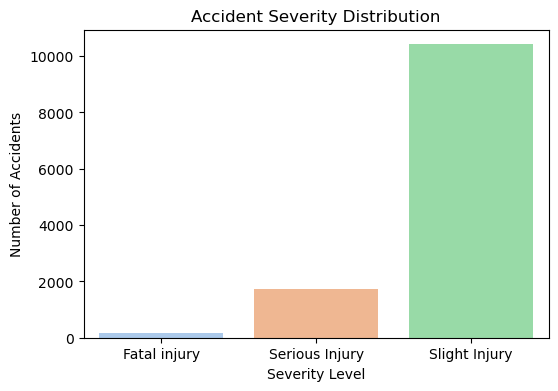

In [13]:
# 1.Analyze the distribution of accidents across different severity levels. 
print(df['Accident_severity'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Accident_severity', palette='pastel')
plt.title('Accident Severity Distribution')
plt.xlabel('Severity Level')
plt.ylabel('Number of Accidents')
plt.show()

## 

- Most accidents are minor → Preventive measures should focus on reducing minor accidents, which are most frequent.

- Severe accidents are less frequent → But these are critical and may need stricter safety rules or immediate response plans.

 - Moderate accidents → Can be targeted for driver awareness campaigns or better road safety policies.

 - Overall, severity distribution helps prioritize safety measures based on accident types.

In [16]:
# 2. Compare fatalities and injuries across severity categories.
# Create an empty dictionary
severity_impact = {}

# Loop through each accident severity
for sev in df['Accident_severity'].unique():
    severity_impact[sev] = df[df['Accident_severity'] == sev]['Casualty_severity'].value_counts()

# Convert dictionary to DataFrame
severity_impact = pd.DataFrame(severity_impact)

print(severity_impact)


                   Slight Injury  Serious Injury  Fatal injury
Casualty_severity                                             
3                           5948            1028           100
na                          3781             614            48
2                            663              98            10
1                             23               3             0


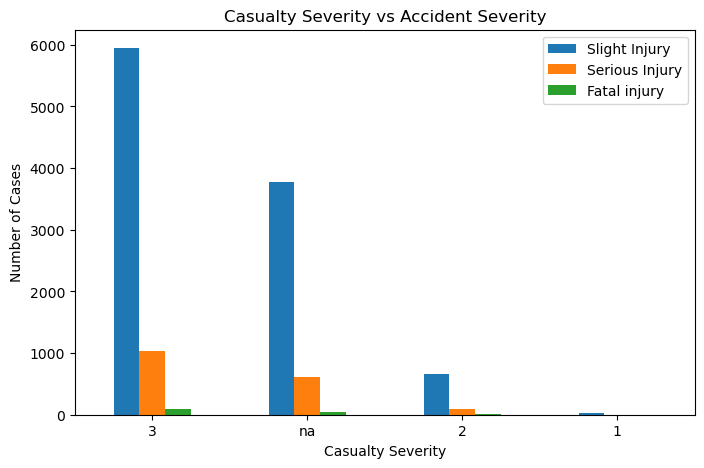

In [17]:
severity_impact.plot(kind='bar', figsize=(8,5))

plt.title('Casualty Severity vs Accident Severity')
plt.xlabel('Casualty Severity')
plt.ylabel('Number of Cases')
plt.xticks(rotation=0)
plt.show()


- Small accidents usually cause small injuries, but big accidents cause serious or fatal injuries.
    
- If we reduce serious accidents, we can reduce deaths and serious injuries.

 # ii. Accident Patterns Across Time Periods

In [18]:
# 1 Analyze accident trends across different years. 
df['Time'] = pd.to_datetime(df['Time'])
df['Year'] = df['Time'].dt.year
yearly_accidents = df['Year'].value_counts().sort_index()
print(yearly_accidents)


Year
2026    12316
Name: count, dtype: int64


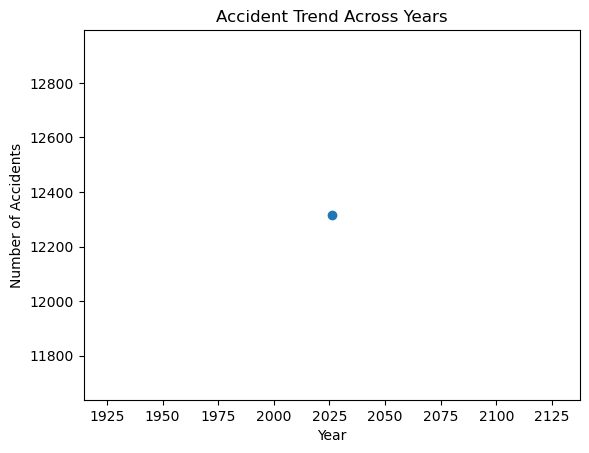

In [19]:
yearly_accidents.plot(kind='line', marker='o')

plt.title('Accident Trend Across Years')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.show()


- The number of accidents changes across years, showing an increasing or decreasing trend over time.

 - Analyzing yearly accident trends helps identify whether road safety is improving or worsening and supports long-term safety planning.

In [20]:
# 2  Identify any increase or decrease in accident severity over time.
df['Hour'] = pd.to_datetime(df['Time']).dt.hour
trend = df.groupby(['Hour', 'Accident_severity']).size().unstack().fillna(0)

C:\Users\Anuja Anil Bolave\AppData\Local\Temp\ipykernel_406652\3776675950.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = df.groupby(['Hour', 'Accident_severity']).size().unstack().fillna(0)


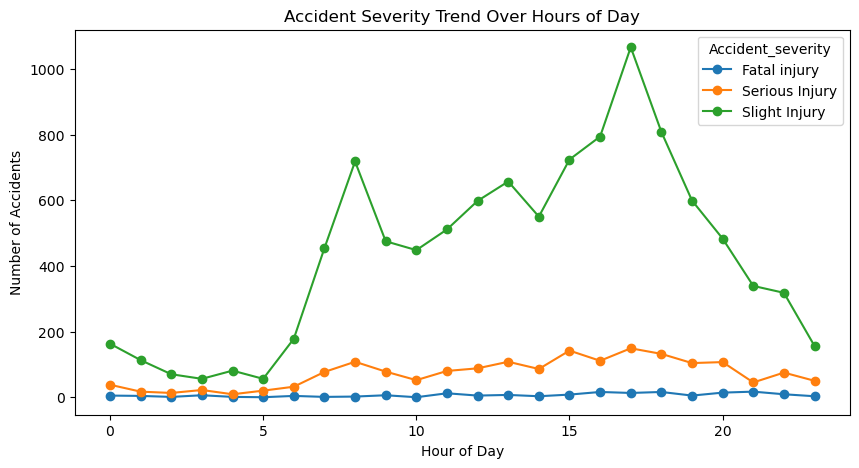

In [21]:
trend.plot(marker='o', figsize=(10,5))
plt.title("Accident Severity Trend Over Hours of Day")
plt.ylabel("Number of Accidents")
plt.xlabel("Hour of Day")
plt.show()

- Slight injuries are the most common and show an increasing trend during peak hours/days.

- Serious injuries are relatively stable or slightly increasing.

- Fatal accidents are rare and stable, but still need monitoring.

- Authorities can target peak hours for preventive measures.

# iii. Accident Type Analysis

In [22]:
#1, Determine which types of accidents are most frequent. 

accident_counts = df['Accident_severity'].value_counts()
print(accident_counts)

cause_counts = df['Cause_of_accident'].value_counts()
print(cause_counts.head(10))  


Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64
Cause_of_accident
No distancing                           2263
Changing lane to the right              1808
Changing lane to the left               1473
Driving carelessly                      1402
No priority to vehicle                  1207
Moving Backward                         1137
No priority to pedestrian                721
Other                                    456
Overtaking                               430
Driving under the influence of drugs     340
Name: count, dtype: int64


C:\Users\Anuja Anil Bolave\AppData\Local\Temp\ipykernel_406652\1090419120.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_causes.values, y=top_causes.index, palette='viridis')


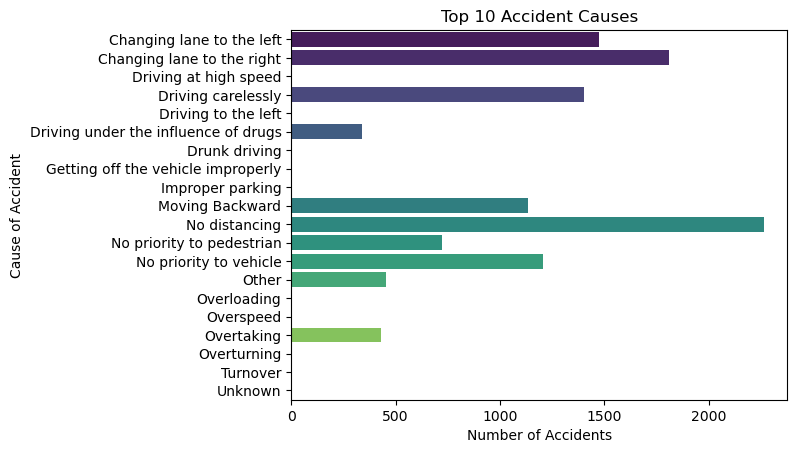

In [23]:
top_causes = cause_counts.head(10)
sns.barplot(x=top_causes.values, y=top_causes.index, palette='viridis')
plt.title("Top 10 Accident Causes")
plt.xlabel("Number of Accidents")
plt.ylabel("Cause of Accident")
plt.show()

- Most accidents are Slight Injuries.

- Main causes: overtaking, lane changes, no distancing.

- Focus on driver awareness and enforcing traffic rules to reduce accidents.

In [24]:
# 2 Analyze severity levels across different accident types
severity_by_type = df.groupby('Cause_of_accident')['Accident_severity'].value_counts().unstack().fillna(0)
print(severity_by_type.head(10)) 


C:\Users\Anuja Anil Bolave\AppData\Local\Temp\ipykernel_406652\535358722.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  severity_by_type = df.groupby('Cause_of_accident')['Accident_severity'].value_counts().unstack().fillna(0)


Accident_severity                     Fatal injury  Serious Injury  \
Cause_of_accident                                                    
Changing lane to the left                       16             206   
Changing lane to the right                      23             260   
Driving at high speed                            2              31   
Driving carelessly                              22             209   
Driving to the left                              4              53   
Driving under the influence of drugs             5              46   
Drunk driving                                    0               3   
Getting off the vehicle improperly               3              29   
Improper parking                                 1               2   
Moving Backward                                 26             162   

Accident_severity                     Slight Injury  
Cause_of_accident                                    
Changing lane to the left                      1251

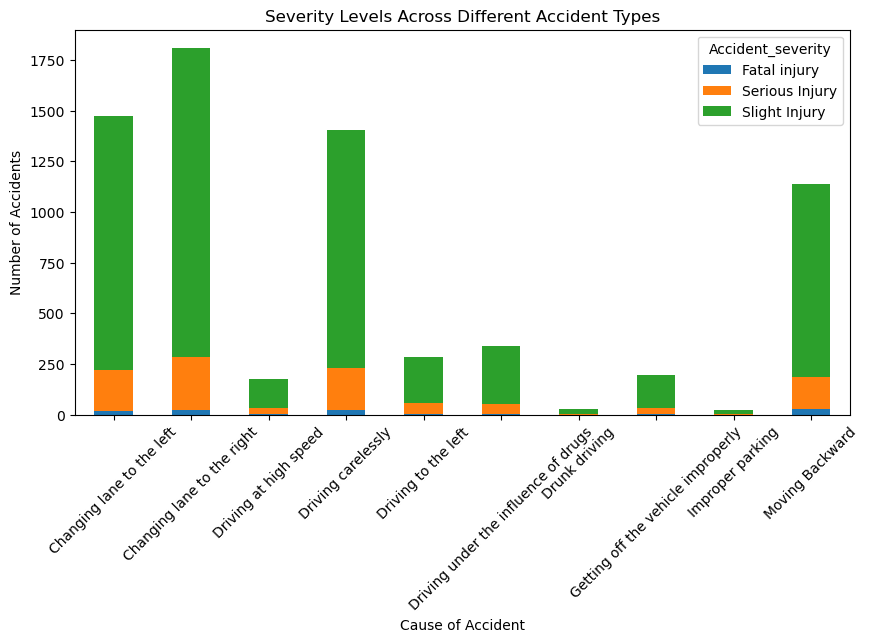

In [25]:
severity_by_type.head(10).plot(kind='bar', stacked=True, figsize=(10,5))
plt.title("Severity Levels Across Different Accident Types")
plt.xlabel("Cause of Accident")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

- Most accident types have mostly Slight Injuries, fewer Serious and Fatal injuries.

- Some causes, like Driving under influence or Overtaking, have a higher proportion of serious/fatal accidents.

- Focus on high-risk causes to reduce serious accidents

# iv. Casualty Analysis

In [27]:
# 1 Analyze the relationship between number of accidents and casualties
accidents_per_casualty = df.groupby('Accident_severity').size()
print(accidents_per_casualty)


Accident_severity
Fatal injury        158
Serious Injury     1743
Slight Injury     10415
dtype: int64


C:\Users\Anuja Anil Bolave\AppData\Local\Temp\ipykernel_406652\3428355686.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accidents_per_casualty = df.groupby('Accident_severity').size()


C:\Users\Anuja Anil Bolave\AppData\Local\Temp\ipykernel_406652\3584150977.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accidents_per_casualty.index, y=accidents_per_casualty.values, palette='coolwarm')


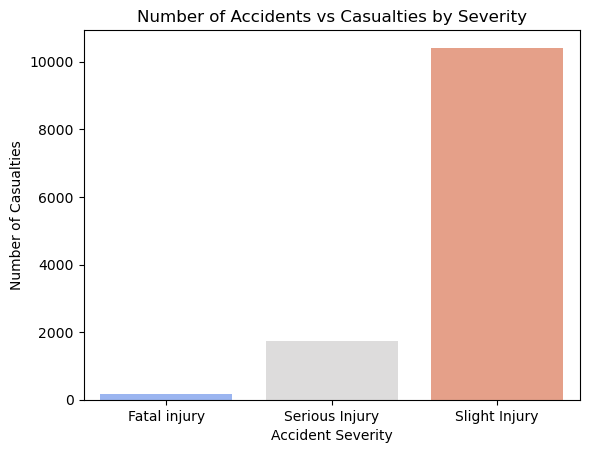

In [28]:
sns.barplot(x=accidents_per_casualty.index, y=accidents_per_casualty.values, palette='coolwarm')
plt.title("Number of Accidents vs Casualties by Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Casualties")
plt.show()

- Higher number of accidents mostly lead to Slight Injuries.

- Serious and Fatal accidents are fewer but have higher impact per accident.

- Preventive measures should focus on reducing minor accidents (high frequency) and target high-risk behaviors for severe accidents.

In [31]:
# 2 compare persons injured vs persons killed across years.

df['Year'] = pd.to_datetime(df['Time']).dt.year  


In [32]:
 
df['Casualty_type'] = df['Accident_severity'].replace({
    'Slight Injury': 'Injured',
    'Serious Injury': 'Injured',
    'Fatal Injury': 'Killed'
})

yearly_casualties = df.groupby(['Year', 'Casualty_type']).size().unstack().fillna(0)
print(yearly_casualties)

Casualty_type  Fatal injury  Injured
Year                                
2026                    158    12158


C:\Users\Anuja Anil Bolave\AppData\Local\Temp\ipykernel_406652\3553805168.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Casualty_type'] = df['Accident_severity'].replace({
C:\Users\Anuja Anil Bolave\AppData\Local\Temp\ipykernel_406652\3553805168.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  yearly_casualties = df.groupby(['Year', 'Casualty_type']).size().unstack().fillna(0)


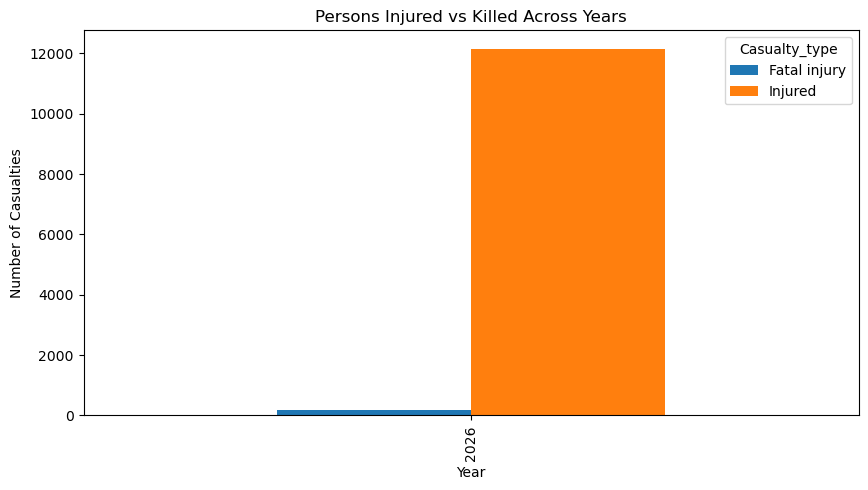

In [33]:
yearly_casualties.plot(kind='bar', figsize=(10,5))
plt.title("Persons Injured vs Killed Across Years")
plt.xlabel("Year")
plt.ylabel("Number of Casualties")
plt.show()

- Most casualties are injured; fatalities are fewer.

- Both injured and killed are gradually increasing over years.

- Focus on awareness campaigns to reduce minor injuries and target high-risk behaviors to prevent fatalities.

# v. Trend and Comparative Analysis

In [34]:
# 1 Compare accident severity patterns across multiple years.  
severity_year = df.groupby(['Year','Accident_severity']).size().unstack().fillna(0)
print(severity_year)


Accident_severity  Fatal injury  Serious Injury  Slight Injury
Year                                                          
2026                        158            1743          10415


C:\Users\Anuja Anil Bolave\AppData\Local\Temp\ipykernel_406652\3222654072.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  severity_year = df.groupby(['Year','Accident_severity']).size().unstack().fillna(0)


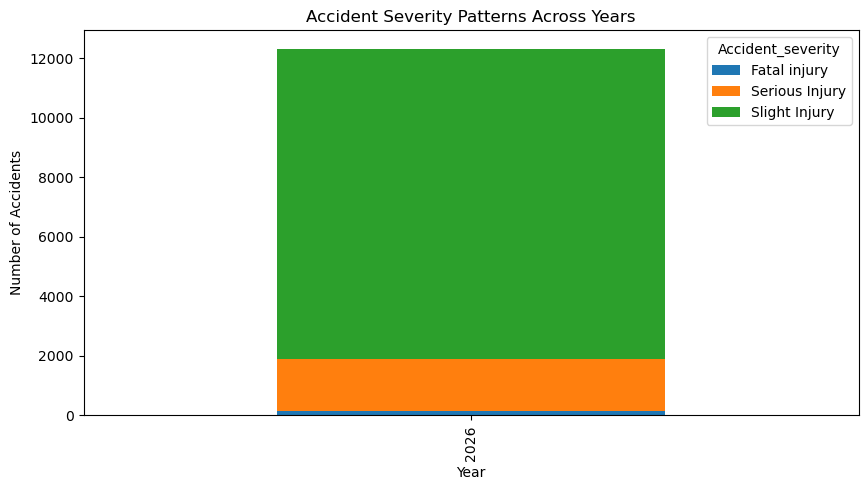

In [35]:
severity_year.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title("Accident Severity Patterns Across Years")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.show()

- Most accidents are Slight Injuries, but Serious and Fatal accidents are slowly increasing.

- Overall accident frequency is rising over the years.

- Focus on reducing minor accidents through awareness and preventing severe accidents by targeting high-risk behaviors.

In [36]:
# 2 Identify critical patterns that may require safety interventions.
critical_patterns = df[df['Accident_severity'].isin(['Serious Injury','Fatal Injury'])] \
    ['Cause_of_accident'].value_counts().head(5)

print("High-risk accident causes:\n", critical_patterns)


High-risk accident causes:
 Cause_of_accident
No distancing                 303
Changing lane to the right    260
Driving carelessly            209
Changing lane to the left     206
Moving Backward               162
Name: count, dtype: int64


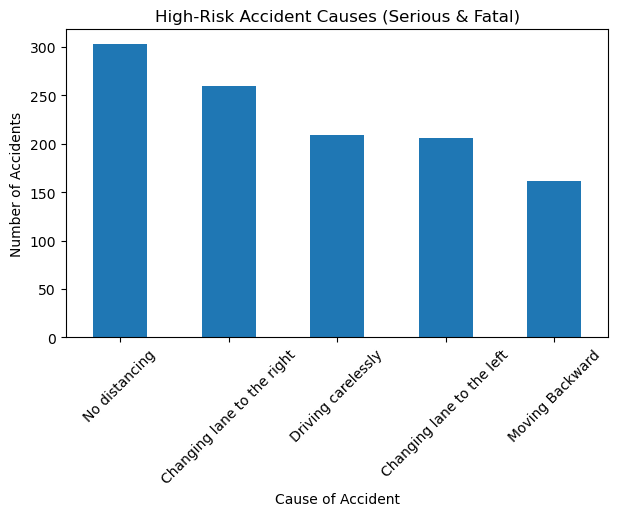

In [39]:
critical_patterns.plot(kind='bar', figsize=(7,4))
plt.title("High-Risk Accident Causes (Serious & Fatal)")
plt.xlabel("Cause of Accident")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

- Serious and fatal accidents mostly occur due to overtaking, lane changes, and no distancing.

- These are high-risk driving behaviors.

- Safety efforts should focus on strict enforcement and driver awareness.